# Module 3 — Photographs: what can the picture tell us that the form does not?

WOCAT documents sustainable land-management (SLM) technologies. Each record is a long
questionnaire — climate, slope, what was built, what happened to biodiversity — plus a few
photographs. There are **1,540 records**, and almost every analysis uses only the questionnaire.

We use **one photograph per record**: the lead image the compiler chose. That is **1,450 photographs**,
no double counting, and it keeps the notebook small enough to run live.

### Three questions

| | question | why we ask it |
|---|---|---|
| **1** | What kinds of photograph are in the archive? | nobody has ever labelled them *(unsupervised)* |
| **2** | Does the photograph predict the **biodiversity** improvement? | the question WOCAT cares about *(supervised)* |
| **3** | Can the photograph **fill in blank fields** in the form? | 18% of records have no `mechanisation` entry |

Two ways of turning a photograph into numbers are compared throughout — **M1**, thirteen numbers we
write by hand, and **M2**, five hundred and twelve numbers a neural network chose for itself.
The whole notebook runs in about a minute.

---
## Setup

In [1]:
import json, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 0                       # fix every random choice so the numbers reproduce
warnings.filterwarnings("ignore")

BLUE, DARK, ORANGE, GREY, RED = "#8fb8dc", "#2f5d8f", "#e08a5a", "#c9ccd1", "#c2410c"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 11, "font.size": 9})

DATA = next(p for p in (pathlib.Path(c).resolve()
                        for c in ["../wocat/data", "../../wocat/data", "wocat/data", "data"])
            if (p / "processed").exists())
THUMBS = DATA / "raw" / "images_thumb"          # 320x240 webp, named <image_id>.webp
CACHE  = pathlib.Path("cache"); CACHE.mkdir(exist_ok=True)

print("data folder :", DATA)
print("photographs :", f"{len(list(THUMBS.glob('*.webp'))):,} thumbnails on disk")


def sheet(groups, cols=8, cell=(120, 90), title=None):
    """Paste thumbnails into a grid: one labelled row per entry of `groups`."""
    if not isinstance(groups, dict):                       # a plain list -> chunk it into rows
        ids = list(groups)
        groups = {" " * (i + 1): ids[i * cols:(i + 1) * cols]
                  for i in range(-(-len(ids) // cols))}
    w, h = cell
    canvas = Image.new("RGB", (cols * w, len(groups) * h), "white")
    for i, ids in enumerate(groups.values()):
        for j, image_id in enumerate(list(ids)[:cols]):
            path = THUMBS / f"{int(image_id)}.webp"
            if path.exists():
                canvas.paste(Image.open(path).convert("RGB").resize((w, h)), (j * w, i * h))
    fig, ax = plt.subplots(figsize=(cols * w / 100, len(groups) * h / 100 + .4))
    ax.imshow(canvas); ax.grid(False); ax.set_xticks([]); ax.tick_params(length=0)
    ax.set_yticks([(i + .5) * h for i in range(len(groups))])
    ax.set_yticklabels(list(groups), fontsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title, loc="left")
    plt.tight_layout(); plt.show()

data folder : /Users/nsdav/Study/CAS AML/Projects/wocat/data
photographs : 4,395 thumbnails on disk


---
# Part 0 — The data

One row per record: its lead photograph, and the questionnaire answers we will use.

In [2]:
index  = pd.read_csv(DATA / "processed" / "images_index.csv")
photos = index[index.is_header == True].reset_index(drop=True)      # one photograph per record
photos = photos[[(THUMBS / f"{i}.webp").exists() for i in photos.image_id]].reset_index(drop=True)


def first(value):
    """Questionnaire answers come as a value, a list, or a dict with a 'value' key."""
    if isinstance(value, dict):
        value = value.get("value")
    if isinstance(value, list):
        return value[0] if value else None
    return value


FIELDS = ["mechanisation", "watersupply", "groundwater", "surfacewater", "soil_depth",
          "landforms", "slopes", "agroclimatic_zone", "landuse", "slm_measures"]

form = pd.DataFrame([
    {"technology_id": record["id"],
     "country": record["selected_version"].get("country"),
     **{f: first(record["selected_version"].get(f)) for f in FIELDS}}
    for record in (json.loads(p.read_text())
                   for p in sorted((DATA / "raw" / "technologies").glob("*.json")))
]).set_index("technology_id")

photos = photos.drop(columns=["country"]).join(form, on="technology_id")

print(f"records with a lead photograph : {len(photos):,}")
print(f"countries                      : {photos.country.nunique()}")
photos[["technology_id", "image_id", "country", "mechanisation", "landuse", "slopes"]].head()

records with a lead photograph : 1,450


countries                      : 107


,technology_id,image_id,country,mechanisation,landuse,slopes
0,7810,10732,SA,MANUAL,FOREST,FLAT
1,7815,10710,SA,MECHANISED,GRAZINGLAND,GENTLE
2,7809,10284,SA,MECHANISED,FOREST,FLAT
3,7706,9432,BR,MANUAL,CROPLAND,GENTLE
4,7717,9456,BR,MANUAL,CROPLAND,GENTLE


### Always look at the pictures first

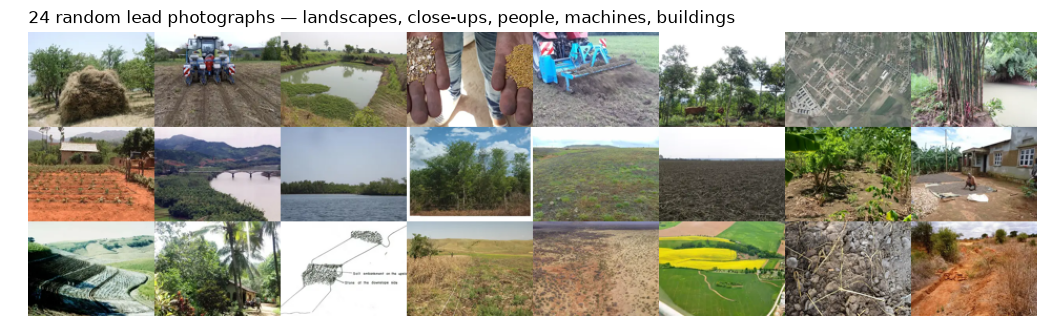

In [3]:
sheet(photos.sample(24, random_state=SEED).image_id, cols=8,
      title="24 random lead photographs — landscapes, close-ups, people, machines, buildings")

### And the reason for Part 3: the form has holes

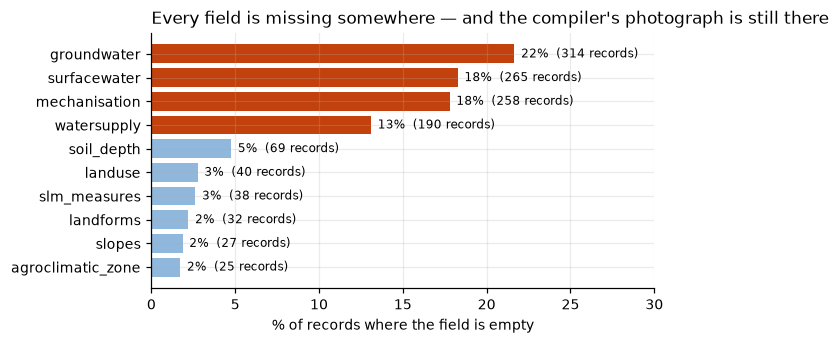

In [4]:
missing = photos[FIELDS].isna().mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.barh(missing.index, missing.values,
        color=[RED if v > 10 else BLUE for v in missing.values])
for name, value in missing.items():
    ax.text(value + .4, name, f"{value:.0f}%  ({int(round(value / 100 * len(photos)))} records)",
            va="center", fontsize=8)
ax.set_xlim(0, 30); ax.set_xlabel("% of records where the field is empty")
ax.set_title("Every field is missing somewhere — and the compiler's photograph is still there",
             loc="left")
plt.tight_layout(); plt.show()

---
# Part 1 — Turning a photograph into numbers

A model cannot read a photograph. It needs a fixed-length list of numbers. There are two ways to
get one, and the whole notebook is a comparison between them.

| | who chooses the numbers | how many | can you name them? |
|---|---|---|---|
| **M1** | we do, by hand, using domain knowledge | 13 | yes — *"how green is it"* |
| **M2** | a neural network, by training on 1.2 million photos | 512 | no |

### M1 — thirteen numbers a human can name

| feature | plain English | why it might matter |
|---|---|---|
| `brightness`, `contrast` | how light, how varied | deserts are bright, forest floors are dark |
| `saturation`, `sat_std` | how vivid the colours | drawings and dusty scenes are pale |
| `green_frac` | pixels greener than red *and* blue | **vegetation** |
| `brown_frac` | warm, dark, unsaturated pixels | **bare soil, dust, dry grass** |
| `sky_frac` | bright bluish pixels | a wide outdoor view has sky |
| `white_frac` | near-white colourless pixels | **paper: diagrams and posters** |
| `edge_mean`, `edge_p90` | how much fine detail | machines are busy, hazy views are smooth |
| `top_bot_diff` | top minus bottom brightness | sky above, ground below = a landscape |
| `rg`, `gb` | average red−green, green−blue | overall colour cast |

In [5]:
def photo_numbers(path):
    """Turn one photograph into 13 numbers we can name."""
    a = np.asarray(Image.open(path).convert("RGB").resize((160, 120)), dtype=np.float32) / 255
    r, g, b = a[..., 0], a[..., 1], a[..., 2]

    value  = a.max(2)                                          # brightness of each pixel
    sat    = np.where(value > 0, (value - a.min(2)) / np.maximum(value, 1e-6), 0)
    grey   = .299 * r + .587 * g + .114 * b                    # perceived lightness
    gy, gx = np.gradient(grey)                                 # how fast brightness changes ...
    edges  = np.hypot(gx, gy)                                  # ... in any direction = an edge
    h      = grey.shape[0]

    return {"brightness":   value.mean(),
            "contrast":     grey.std(),
            "saturation":   sat.mean(),
            "sat_std":      sat.std(),
            "green_frac":   ((g > r + .04) & (g > b + .04)).mean(),
            "brown_frac":   ((r > g) & (g > b) & (sat > .15) & (value < .75)).mean(),
            "sky_frac":     ((b > r + .05) & (b > g + .02) & (value > .5)).mean(),
            "white_frac":   ((value > .9) & (sat < .12)).mean(),
            "edge_mean":    edges.mean(),
            "edge_p90":     np.quantile(edges, .9),
            "top_bot_diff": grey[:h // 3].mean() - grey[2 * h // 3:].mean(),
            "rg":           (r - g).mean(),
            "gb":           (g - b).mean()}


hand = pd.DataFrame([photo_numbers(THUMBS / f"{i}.webp") for i in photos.image_id],
                    index=photos.image_id)
print(f"M1: {hand.shape[1]} hand-made numbers for {len(hand):,} photographs")
hand.head(3).round(3)

M1: 13 hand-made numbers for 1,450 photographs


,brightness,contrast,saturation,sat_std,green_frac,brown_frac,sky_frac,white_frac,edge_mean,edge_p90,top_bot_diff,rg,gb
image_id,,,,,,,,,,,,,
10732,0.516,0.232,0.300,0.147,0.0,0.528,0.18,0.001,0.053,0.121,0.389,0.025,0.053
10710,0.628,0.148,0.538,0.093,0.0,0.694,0.00,0.000,0.057,0.123,0.184,0.129,0.201
10284,0.600,0.044,0.155,0.017,0.0,0.574,0.00,0.000,0.023,0.058,0.023,0.026,0.067


Do they mean what we think? The photograph that scores highest on each one:

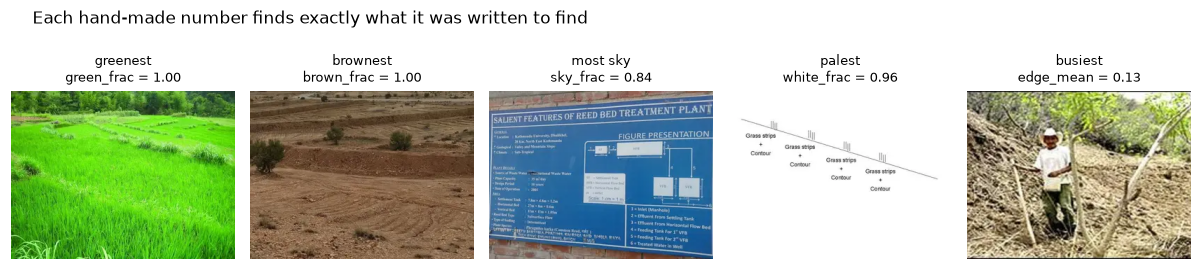

In [6]:
picks = {"greenest": "green_frac", "brownest": "brown_frac", "most sky": "sky_frac",
         "palest": "white_frac", "busiest": "edge_mean"}

fig, axes = plt.subplots(1, len(picks), figsize=(11, 2.5))
for ax, (label, feature) in zip(axes, picks.items()):
    image_id = hand[feature].idxmax()
    ax.imshow(Image.open(THUMBS / f"{image_id}.webp"))
    ax.set_axis_off(); ax.grid(False)
    ax.set_title(f"{label}\n{feature} = {hand[feature][image_id]:.2f}", fontsize=8.5)
fig.suptitle("Each hand-made number finds exactly what it was written to find", y=1.04, x=.03,
             ha="left", fontsize=11)
plt.tight_layout(); plt.show()

### M2 — five hundred and twelve numbers a network chose for itself

A **convolutional neural network** slides small windows over the image. Early layers find edges,
middle layers combine them into textures, late layers combine those into *"leafy thing"*,
*"wheeled metal thing"*, *"person-shaped thing"*. **Nobody programs those patterns** — they are
learned from millions of examples.

We have 1,450 photographs, nowhere near enough to learn them. So we use **transfer learning**:
take **ResNet18**, already trained on 1.2 million ImageNet photos, **change nothing**, cut off its
final naming layer, and read the 512 numbers underneath. That is the network's own description of
the photograph.

In [7]:
EMB_PATH = CACHE / "header_emb_resnet18.npy"

if EMB_PATH.exists():
    emb = np.load(EMB_PATH)
else:
    import torch, torchvision
    from torchvision import transforms

    device = ("mps" if torch.backends.mps.is_available()
              else "cuda" if torch.cuda.is_available() else "cpu")
    net = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = torch.nn.Identity()       # cut off the layer that names an ImageNet class
    net.eval().to(device)              # frozen: not one weight is trained here

    prep = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                               transforms.Normalize([.485, .456, .406], [.229, .224, .225])])
    batches = []
    with torch.no_grad():
        for start in range(0, len(photos), 64):
            images = [prep(Image.open(THUMBS / f"{i}.webp").convert("RGB"))
                      for i in photos.image_id[start:start + 64]]
            batches.append(net(torch.stack(images).to(device)).cpu().numpy())
    emb = np.vstack(batches)
    np.save(EMB_PATH, emb)
    print(f"computed on {device}")

print(f"M2: {emb.shape[1]} learned numbers for {emb.shape[0]:,} photographs")

computed on mps
M2: 512 learned numbers for 1,450 photographs


---
# Part 2 — What kinds of photograph are in there?  *(unsupervised)*

Nobody has told the computer any answers. **k-means** finds groups without labels: drop `k` points
into the data, every photo joins the nearest one, each point moves to the middle of its members,
repeat.

Two preparations matter. **Standardising** puts every feature on the same scale, so `brightness`
(0–1) does not drown out `contrast` (0.04–0.37). And for the 512 learned numbers we run **PCA**
first, squeezing them to the 50 directions carrying the most variation — k-means behaves badly in
512 dimensions.

Same algorithm, same `k`, same photographs. **The only thing that changes is who chose the numbers.**

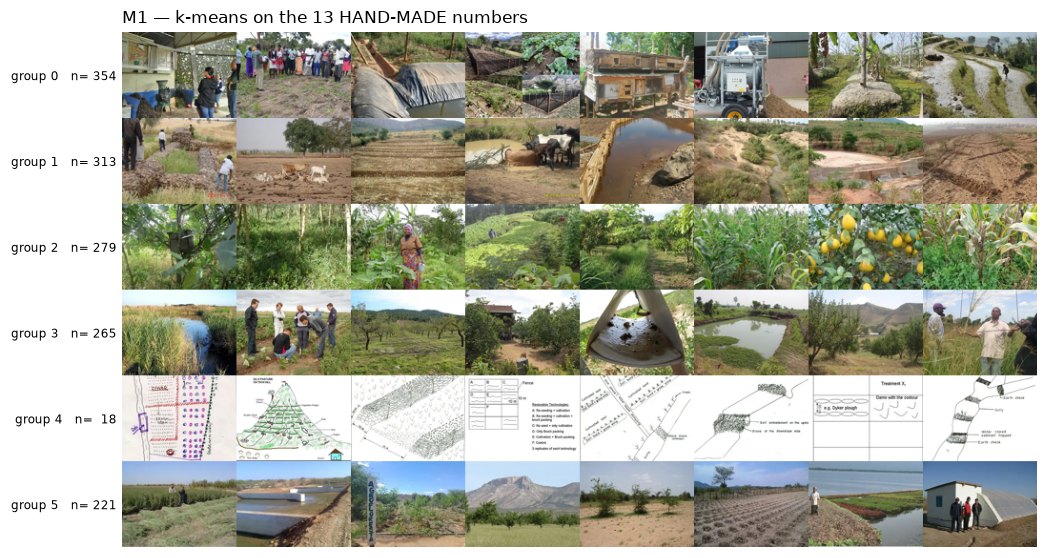

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

K = 6
X_hand = StandardScaler().fit_transform(hand.values)                              # 1450 x 13
Z      = PCA(50, random_state=SEED).fit_transform(StandardScaler().fit_transform(emb))  # 1450 x 50

km_hand = KMeans(K, random_state=SEED, n_init=20).fit(X_hand)
km_cnn  = KMeans(K, random_state=SEED, n_init=20).fit(Z)


def typical(km, X, cluster, n=8):
    """The n photographs sitting closest to a cluster's centre."""
    distance = np.linalg.norm(X - km.cluster_centers_[cluster], axis=1)
    distance[km.labels_ != cluster] = np.inf
    return photos.image_id.values[np.argsort(distance)[:n]]


sheet({f"group {c}   n={(km_hand.labels_ == c).sum():>4}": typical(km_hand, X_hand, c)
       for c in range(K)}, title="M1 — k-means on the 13 HAND-MADE numbers")

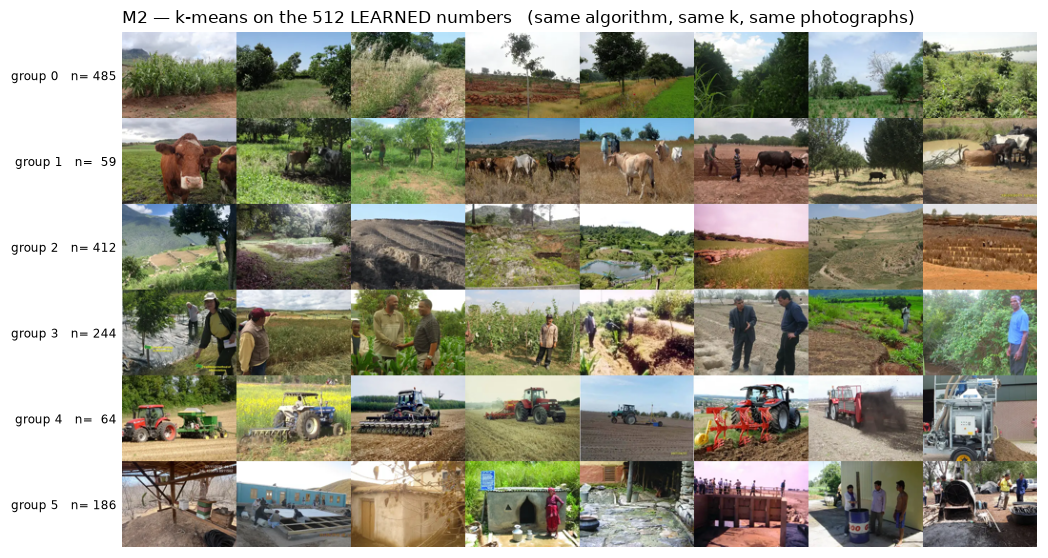

In [9]:
sheet({f"group {c}   n={(km_cnn.labels_ == c).sum():>4}": typical(km_cnn, Z, c)
       for c in range(K)},
      title="M2 — k-means on the 512 LEARNED numbers   (same algorithm, same k, same photographs)")

### The comparison, in one sentence

**Hand-made numbers found colour** — green things, brown things, dark things. The one group with a
real subject is the pale one: `white_frac` collects the technical drawings, because we wrote a
number for exactly that. Nothing in the thirteen can tell a tractor from a stone wall, though,
because both are *"grey, detailed, not very green"*.

**Learned numbers found subject matter.** The rows name themselves, so we name them (the group
numbers themselves are arbitrary and can shuffle between runs):

In [10]:
NAMES = {0: "green crops & fields", 1: "livestock",       2: "open terrain & slopes",
         3: "people at work",       4: "machinery",       5: "built structures"}

photos["group"] = [NAMES[c] for c in km_cnn.labels_]
photos["group"].value_counts().to_frame("photographs")

,photographs
group,
green crops & fields,485
open terrain & slopes,412
people at work,244
built structures,186
machinery,64
livestock,59


### Are these groups real, or an artefact of the algorithm?

The test: do they line up with something in the **questionnaire**, which the clustering never saw?

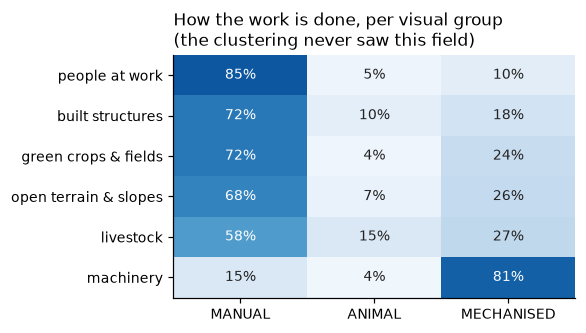

In [11]:
order = ["MANUAL", "ANIMAL", "MECHANISED"]
cross = (pd.crosstab(photos.group, photos.mechanisation, normalize="index")
           .reindex(columns=order) * 100).sort_values("MECHANISED")

fig, ax = plt.subplots(figsize=(5.4, 3.1))
ax.imshow(cross.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(3), order, fontsize=9)
ax.set_yticks(range(len(cross)), cross.index, fontsize=9)
ax.grid(False)
for i in range(len(cross)):
    for j in range(3):
        v = cross.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                color="white" if v > 55 else "#222")
ax.set_title("How the work is done, per visual group\n(the clustering never saw this field)",
             loc="left")
plt.tight_layout(); plt.show()

**The `machinery` group is overwhelmingly drawn from records marked MECHANISED**, against a much
lower share everywhere else. The clustering saw only pixels. That agreement is the evidence that
the group is a real thing in the world — and it is the hint that leads to Part 3.

---
# Part 3 — Does the photograph predict the biodiversity improvement?

This is the question WOCAT cares about, and the one Module 2 answered from the questionnaire.
The questionnaire rates the biodiversity impact from −3 to +3 on eight indicators; the headline
one is **biomass / above-ground C**. We split it at the median: *improved a lot* against
*improved a little*.

### Two rules for every score below

**1 — Never score a model on data it was trained on.** We hide a fifth of the rows, train on the
rest, test on the hidden fifth, and repeat five times. That is **cross-validation**.

**2 — Split by country, not at random.** WOCAT photographs arrive in country-sized batches — same
compiler, same trip, same camera. Split at random and the model recognises the hillside, not the
terrace. That is **leakage**. So whole countries stay together, and the question becomes the honest
one: *given a country you have never seen, can you tell?*

We report **ROC-AUC**: the chance that the model ranks a random positive above a random negative.
**0.50 is a coin flip.**

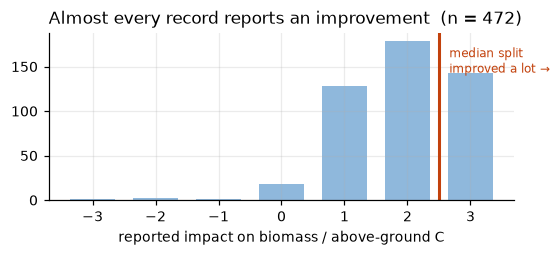

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline

DESCRIPTIONS = [("M1 · 13 hand-made", X_hand), ("M2 · 512 learned", emb)]


def model():
    """Logistic regression. Small C = strong regularisation, needed with 512 columns."""
    return make_pipeline(StandardScaler(),
                         LogisticRegression(C=1e-3, max_iter=3000, class_weight="balanced"))


def evaluate(X, y, groups):
    """Out-of-fold probabilities from 5 country-grouped folds."""
    folds = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups))
    return cross_val_predict(model(), X, y, cv=folds, method="predict_proba")[:, 1]


results = []


def compare(question, mask, y):
    """Run both descriptions on the same rows and folds; remember the scores."""
    groups = photos.country[mask].astype(str).to_numpy(dtype=object)
    row, probabilities = {"question": question, "records": int(mask.sum()),
                          "% positive": round(100 * y.mean())}, {}
    for name, X in DESCRIPTIONS:
        probabilities[name] = evaluate(X[mask], y, groups)
        row[name] = roc_auc_score(y, probabilities[name])
    results.append(row)
    return probabilities


def plot_roc(y, probabilities, title):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot([0, 1], [0, 1], color=GREY, lw=1.5, ls="--", label="coin flip  (AUC 0.50)")
    for (name, p), colour in zip(probabilities.items(), [BLUE, DARK]):
        fpr, tpr, _ = roc_curve(y, p)
        ax.plot(fpr, tpr, color=colour, lw=2, label=f"{name}  (AUC {roc_auc_score(y, p):.2f})")
    ax.set_xlabel("false alarms"); ax.set_ylabel("correct catches")
    ax.set_title(title, loc="left"); ax.legend(loc="lower right", frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()


tech  = pd.read_csv(DATA / "processed" / "technologies_biodiversity.csv").set_index("technology_id")
score = tech.bio_biomass_above_ground_C.reindex(photos.technology_id).to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 2.4))
counts = pd.Series(score).round().value_counts().reindex(range(-3, 4), fill_value=0)
ax.bar(counts.index, counts.values, color=BLUE, width=.72)
ax.axvline(np.nanmedian(score) + .5, color=RED, lw=2)
ax.text(np.nanmedian(score) + .6, counts.max() * .8, " median split\n improved a lot →",
        color=RED, fontsize=8)
ax.set_xticks(range(-3, 4))
ax.set_xlabel("reported impact on biomass / above-ground C")
ax.set_title(f"Almost every record reports an improvement  (n = {int(np.sum(~np.isnan(score)))})",
             loc="left")
plt.tight_layout(); plt.show()

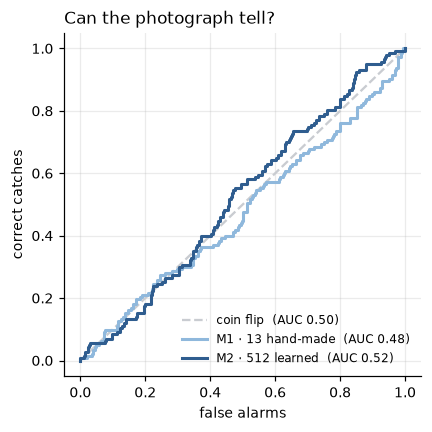

,records,% positive,M1 · 13 hand-made,M2 · 512 learned
question,,,,
biodiversity: big biomass gain?,472,30,0.476,0.522
biodiversity: high average of all 8 indicators?,878,49,0.507,0.526


In [13]:
mask  = ~np.isnan(score) & photos.country.notna().to_numpy()
y_bio = (score[mask] > np.nanmedian(score[mask])).astype(int)

probabilities = compare("biodiversity: big biomass gain?", mask, y_bio)
plot_roc(y_bio, probabilities, "Can the photograph tell?")

mean_score = tech.biodiversity_score_mean.reindex(photos.technology_id).to_numpy()
mask_all   = ~np.isnan(mean_score) & photos.country.notna().to_numpy()
compare("biodiversity: high average of all 8 indicators?", mask_all,
        (mean_score[mask_all] > np.nanmedian(mean_score[mask_all])).astype(int))

pd.DataFrame(results).set_index("question").round(3)

### The answer is no — and that is not a failure of the pictures

Both curves hug the diagonal. **A photograph of a terrace can tell you *"there is a terrace"*. It
cannot tell you *"this terrace will raise biodiversity by +2 over five years."*** The outcome is a
five-year ecological process, and the camera was there for one afternoon.

So we stop asking the picture to predict the future, and ask it to describe the present.

---
# Part 4 — Can the photograph fill in the blanks?

Part 0 showed the holes. **258 records (18%) have no `mechanisation` entry** — the field that says
whether the work is done by hand, by animal or by machine.

That blank is different from a biodiversity score in one decisive way: **the answer already exists
in the world, and it is sitting in the photograph.** So this time we are not predicting the future,
we are reading the evidence.

We train on the 1,120 records where the field *is* filled in (MANUAL vs MECHANISED), on the same
country-grouped folds.

field filled in : 1,120 records   (26% of them MECHANISED)
field blank     : 258 records   <- what we want to help with


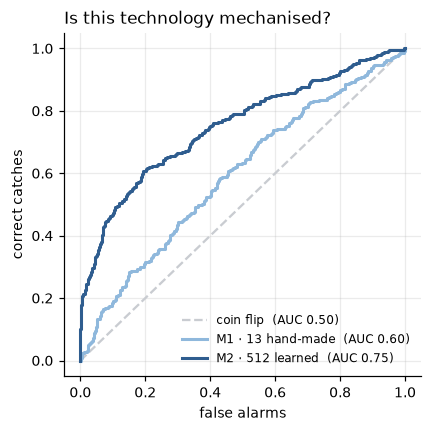

In [14]:
mechanised = photos.mechanisation
known = mechanised.isin(["MANUAL", "MECHANISED"]).to_numpy() & photos.country.notna().to_numpy()
blank = mechanised.isna().to_numpy()

y_mech = (mechanised[known] == "MECHANISED").astype(int).to_numpy()
print(f"field filled in : {known.sum():,} records   ({y_mech.mean():.0%} of them MECHANISED)")
print(f"field blank     : {blank.sum():,} records   <- what we want to help with")

probabilities = compare("mechanisation: is the work done by machine?", known, y_mech)
plot_roc(y_mech, probabilities, "Is this technology mechanised?")

**0.75 against 0.50, from a photograph alone** — and the hand-made numbers reach only 0.60. Colour
and busyness cannot describe *an object*; a network trained on 1.2 million photographs does it
without being asked. This is the clearest M1-versus-M2 gap in the notebook.

### But an AUC is not a deliverable. A reviewer's queue is.

We do not want to *set* the field. We want to hand a WOCAT editor a short list worth checking. So
the number that matters is **how often the model is right about the records it is most confident
about**.

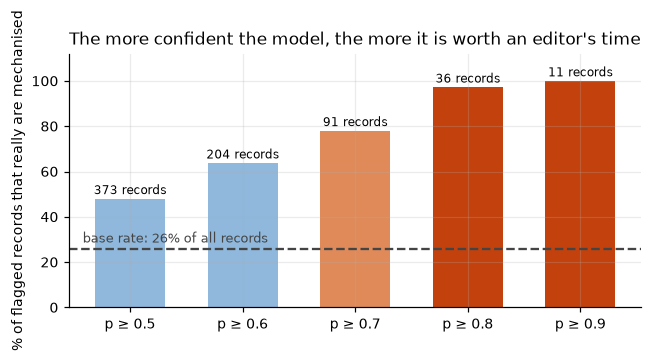

,confidence,records flagged,actually mechanised
0,p ≥ 0.5,373,0.48
1,p ≥ 0.6,204,0.64
2,p ≥ 0.7,91,0.78
3,p ≥ 0.8,36,0.97
4,p ≥ 0.9,11,1.00


In [15]:
p_mech = probabilities["M2 · 512 learned"]
base   = y_mech.mean()

table = pd.DataFrame([
    {"confidence": f"p ≥ {t:.1f}", "records flagged": int((p_mech >= t).sum()),
     "actually mechanised": y_mech[p_mech >= t].mean() if (p_mech >= t).sum() else np.nan}
    for t in [.5, .6, .7, .8, .9]])

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(range(len(table)), table["actually mechanised"] * 100,
              color=[BLUE, BLUE, ORANGE, RED, RED], width=.62)
ax.axhline(base * 100, color="#444", lw=1.5, ls="--")
ax.text(-.42, base * 100 + 3, f"base rate: {base:.0%} of all records",
        ha="left", fontsize=8.5, color="#444")
for bar, n in zip(bars, table["records flagged"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{n} records",
            ha="center", fontsize=8)
ax.set_xticks(range(len(table)), table.confidence)
ax.set_ylim(0, 112); ax.set_ylabel("% of flagged records that really are mechanised")
ax.set_title("The more confident the model, the more it is worth an editor's time", loc="left")
plt.tight_layout(); plt.show()

table.round(2)

Blindly, one record in four is mechanised. Among the 36 records the model is most confident about,
**35 really are** — and of the top 11, all of them. Fewer records are flagged as the bar rises, and
that is fine: the job is not to find every mechanised record, it is to **put the right records at
the top of an editor's queue**.

### Now run it on the records where the field is genuinely empty

258 records have no mechanisation entry. Ranked by their photograph:
  p ≥ 0.6 :  33 records   <- the review queue
  p ≥ 0.8 :   6 records   <- check these first


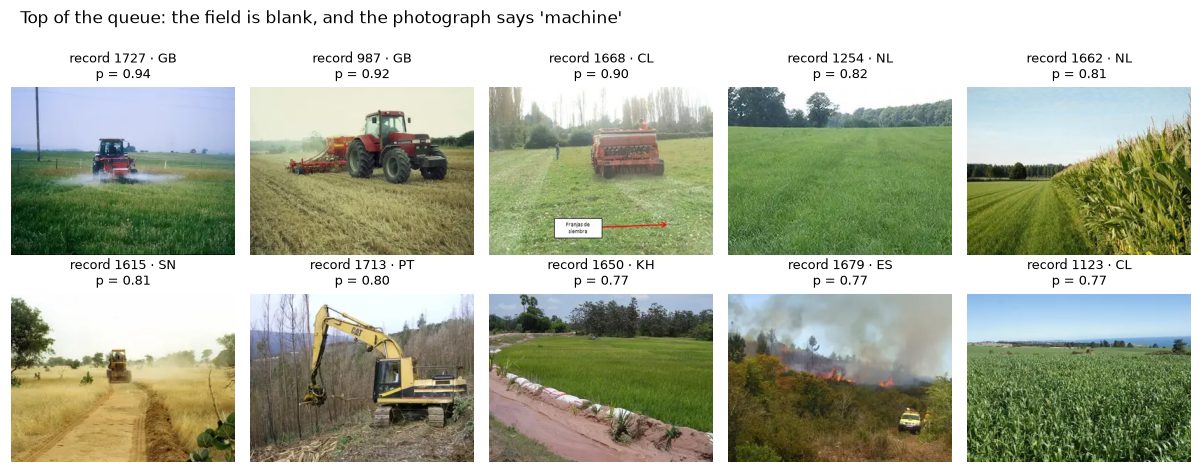

In [16]:
fitted = model().fit(emb[known], y_mech)
queue = (pd.DataFrame({"technology_id": photos.technology_id[blank].to_numpy(),
                       "image_id":      photos.image_id[blank].to_numpy(),
                       "country":       photos.country[blank].to_numpy(),
                       "p_mechanised":  fitted.predict_proba(emb[blank])[:, 1]})
         .sort_values("p_mechanised", ascending=False).reset_index(drop=True))

print(f"{blank.sum()} records have no mechanisation entry. Ranked by their photograph:")
print(f"  p ≥ 0.6 : {(queue.p_mechanised >= .6).sum():>3} records   <- the review queue")
print(f"  p ≥ 0.8 : {(queue.p_mechanised >= .8).sum():>3} records   <- check these first")

fig, axes = plt.subplots(2, 5, figsize=(11, 4.4))
for ax, row in zip(axes.ravel(), queue.head(10).itertuples()):
    ax.imshow(Image.open(THUMBS / f"{row.image_id}.webp"))
    ax.set_axis_off(); ax.grid(False)
    ax.set_title(f"record {row.technology_id} · {row.country}\np = {row.p_mechanised:.2f}",
                 fontsize=8.5)
fig.suptitle("Top of the queue: the field is blank, and the photograph says 'machine'",
             x=.02, y=1.0, ha="left", fontsize=11)
plt.tight_layout(); plt.show()

### Read it the way an editor would

- ✅ *"These records have no mechanisation entry and their photographs look mechanised. Please check
  them first."*
- ❌ *"Set `mechanisation = MECHANISED` on these records."*

One honest caveat: **a blank field is not a random blank.** If compilers skip the field precisely
when the answer is awkward, the records we are ranking are systematically unlike the records we
trained on. A real deployment would have to check that.

---
# Part 5 — Everything on one chart

Two more questionnaire fields, scored exactly the same way, to place the two results side by side:
things that are **in the frame** against things that are **in the future**.

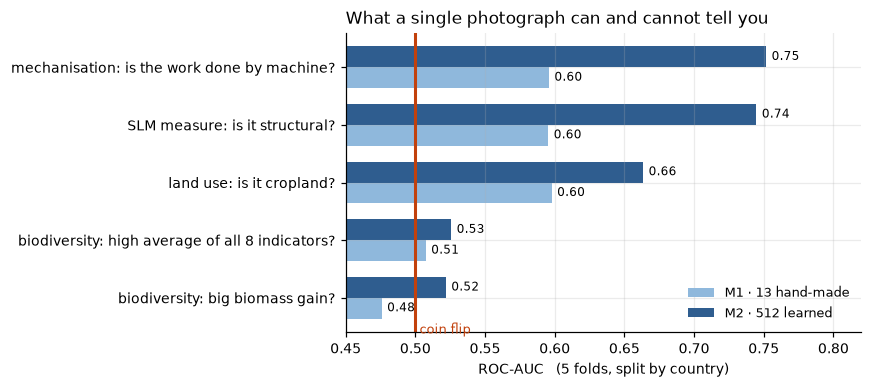

,records,% positive,M1 · 13 hand-made,M2 · 512 learned
question,,,,
biodiversity: big biomass gain?,472,30,0.476,0.522
biodiversity: high average of all 8 indicators?,878,49,0.507,0.526
land use: is it cropland?,1410,76,0.598,0.663
SLM measure: is it structural?,1412,18,0.595,0.745
mechanisation: is the work done by machine?,1120,26,0.596,0.752


In [17]:
for question, column, positive in [("land use: is it cropland?", "landuse", "CROPLAND"),
                                   ("SLM measure: is it structural?", "slm_measures", "STRUCTURAL")]:
    m = photos[column].notna().to_numpy() & photos.country.notna().to_numpy()
    compare(question, m, (photos[column][m] == positive).astype(int).to_numpy())

table = pd.DataFrame(results).set_index("question").sort_values("M2 · 512 learned")

fig, ax = plt.subplots(figsize=(8, 3.6))
y_pos, height = np.arange(len(table)), .36
for i, (name, colour) in enumerate([("M1 · 13 hand-made", BLUE), ("M2 · 512 learned", DARK)]):
    ax.barh(y_pos + (i - .5) * height, table[name], height=height, color=colour, label=name)
    for y, v in zip(y_pos + (i - .5) * height, table[name]):
        ax.text(v + .004, y, f"{v:.2f}", va="center", fontsize=8)
ax.axvline(.5, color=RED, lw=2)
ax.text(.503, -.62, "coin flip", color=RED, fontsize=8.5)
ax.set_yticks(y_pos, table.index, fontsize=9)
ax.set_xlim(.45, .82); ax.set_xlabel("ROC-AUC   (5 folds, split by country)")
ax.set_title("What a single photograph can and cannot tell you", loc="left")
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
plt.tight_layout(); plt.show()

table.round(3)

---
# What we found

1. **The archive has a visual taxonomy that nobody recorded.** Six kinds of photograph — crops,
   livestock, open terrain, people, machinery, structures — found with **no labels at all**, and
   confirmed against a questionnaire field the clustering never saw.
2. **Who chooses the numbers decides what you can see.** Thirteen hand-made numbers cluster by
   *colour*; 512 learned numbers cluster by *subject*. The learned description wins every question
   — by 15 AUC points where the answer is in the frame, and by nothing that matters where it is not.
3. **The photograph says nothing about the ecological outcome.** AUC 0.48–0.53, a coin flip. The
   picture shows what was built, not what happened over the following five years.
4. **The photograph does describe what was built** — mechanisation 0.75, structural measures 0.74,
   land use 0.66, all from one thumbnail and no questionnaire text.
5. **So the useful deliverable is gap-filling, not prediction.** Of the 36 records the model is most
   confident about, **35 really are mechanised** against a 26% base rate. That turns 258 blank
   fields into a short, ranked queue a WOCAT editor can work through.

### What we would do next

* use **all ~4,400 photographs**, not just the lead one, and pool them per record;
* **fine-tune** the network instead of freezing it;
* extend the queue to the other gappy fields — `groundwater`, `surfacewater`, `watersupply`.